In [1]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [2]:
%pip install ultralytics roboflow  supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/5

In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.121 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.4/112.6 GB disk)


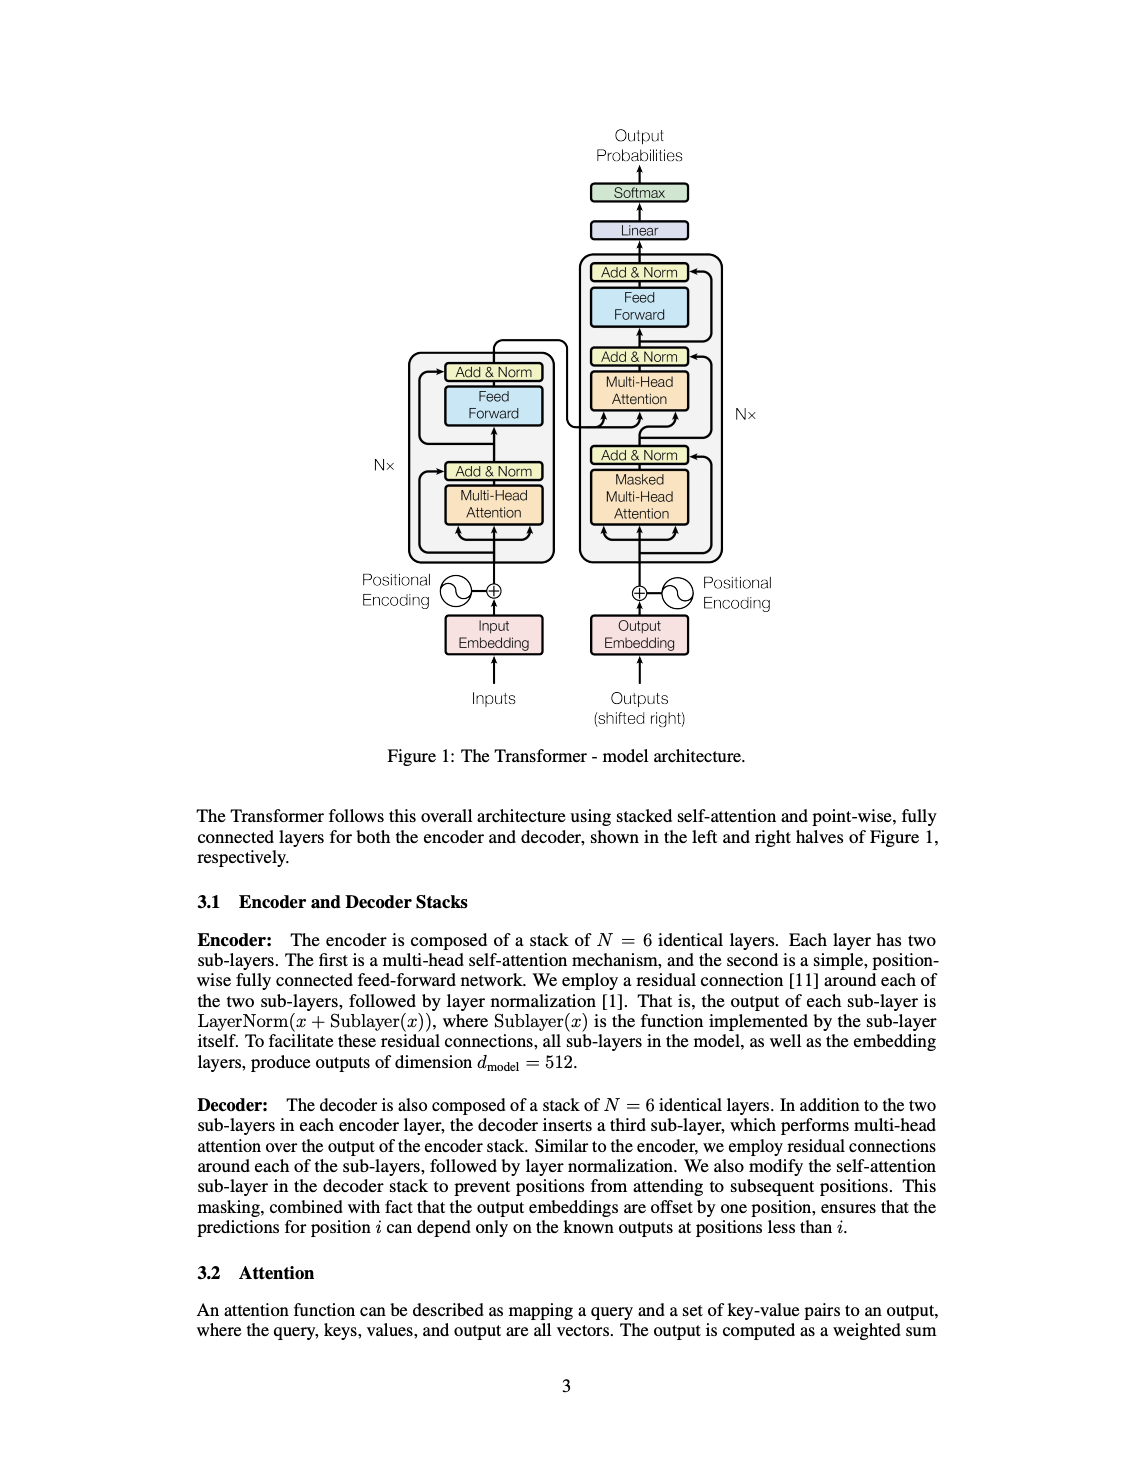

In [5]:
from IPython.display import Image as IPyimage
IPyimage(filename=f'/content/download.png',width = 600)

In [6]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open('/content/download.png')
result = model.predict(image,conf=0.25)[0]

100%|██████████| 5.35M/5.35M [00:00<00:00, 326MB/s]



0: 640x512 (no detections), 73.8ms
Speed: 25.7ms preprocess, 73.8ms inference, 130.8ms postprocess per image at shape (1, 3, 640, 512)


In [7]:
result.boxes.xyxy



tensor([], device='cuda:0', size=(0, 4))

In [8]:
result.boxes.conf

tensor([], device='cuda:0')

In [9]:
result.boxes.cls

tensor([], device='cuda:0')

In [10]:
import supervision as sv
detections = sv.Detections.from_ultralytics(result)

In [11]:
detections

Detections(xyxy=array([], shape=(0, 4), dtype=float32), mask=None, confidence=array([], dtype=float32), class_id=array([], dtype=int64), tracker_id=None, data={'class_name': array([], dtype=float64)}, metadata={})

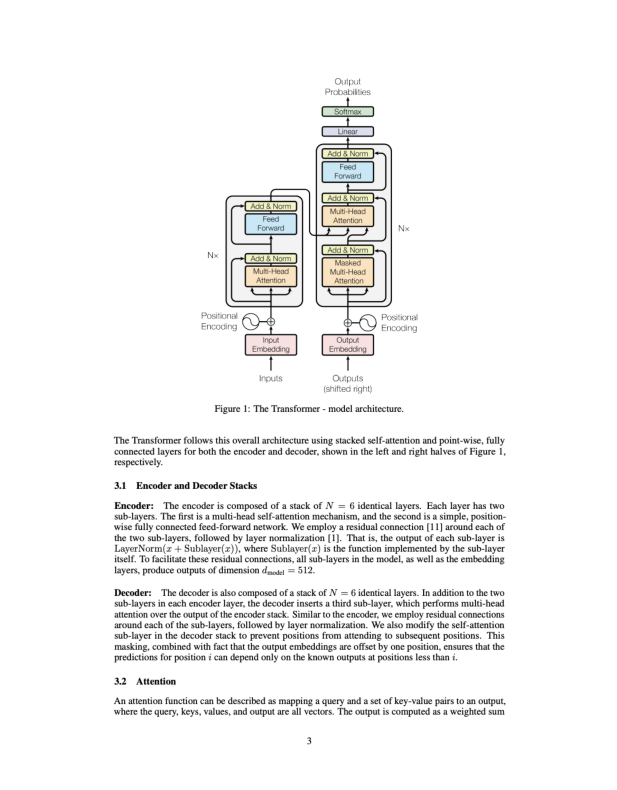

In [15]:
box_annotoator  = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotoator.annotate(annotated_image,detections=detections)
annotated_image = label_annotator.annotate(annotated_image,detections=detections)
sv.plot_image(annotated_image,size=(10,10))

This  image provided was unnknown to the yolo library therefore it could not detect/create any annotations or bounding boxes.

In [17]:
#Now creating annotations on a known immage
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open('/content/cat.jpg')
result = model.predict(image,conf=0.25)[0]


0: 448x640 1 cat, 48.0ms
Speed: 2.2ms preprocess, 48.0ms inference, 239.2ms postprocess per image at shape (1, 3, 448, 640)


In [19]:
result.boxes.xyxy

tensor([[100.8215,  12.8905, 189.9707, 191.2644]], device='cuda:0')

In [20]:
result.boxes.conf

tensor([0.8765], device='cuda:0')

In [21]:
result.boxes.cls

tensor([15.], device='cuda:0')

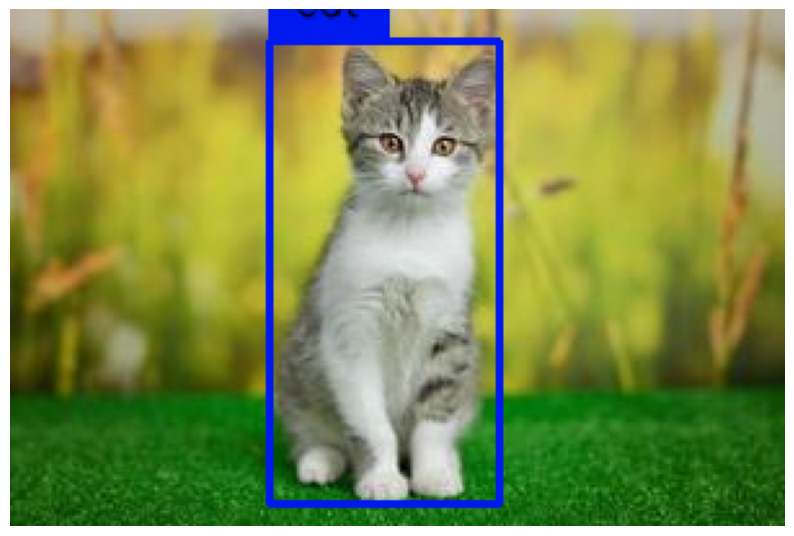

In [24]:
detections = sv.Detections.from_ultralytics(result)

box_annotoator  = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotoator.annotate(annotated_image,detections=detections)
annotated_image = label_annotator.annotate(annotated_image,detections=detections)

sv.plot_image(annotated_image,size=(10,10))

# Fine tuning
fine tuning yolo11 on a custom dataset.

In [27]:
!mkdir (HOME)/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

rf = Roboflow(api_key="QhFmKKH4Z9qDfOjRekBt")
project = rf.workspace("huyifei").project("tft-id")
version = project.version(1)
dataset = version.download("yolov11")

/bin/bash: -c: line 1: syntax error near unexpected token `HOME'
/bin/bash: -c: line 1: `mkdir (HOME)/datasets'
[Errno 2] No such file or directory: '/content/datasets'
/content
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to TFT-ID-1 in yolov11:: 100%|██████████| 17224/17224 [00:16<00:00, 1017.98it/s]


In [28]:
dataset.location


'/content/TFT-ID-1'

In [30]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=5 imgsz=640 plots=True

/content
Ultralytics 8.3.121 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/TFT-ID-1/data.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, li

In [31]:
!ls {HOME}/runs/detect/train/

args.yaml			 PR_curve.png	   val_batch0_labels.jpg
confusion_matrix_normalized.png  R_curve.png	   val_batch0_pred.jpg
confusion_matrix.png		 results.csv	   val_batch1_labels.jpg
F1_curve.png			 results.png	   val_batch1_pred.jpg
labels_correlogram.jpg		 train_batch0.jpg  val_batch2_labels.jpg
labels.jpg			 train_batch1.jpg  val_batch2_pred.jpg
P_curve.png			 train_batch2.jpg  weights


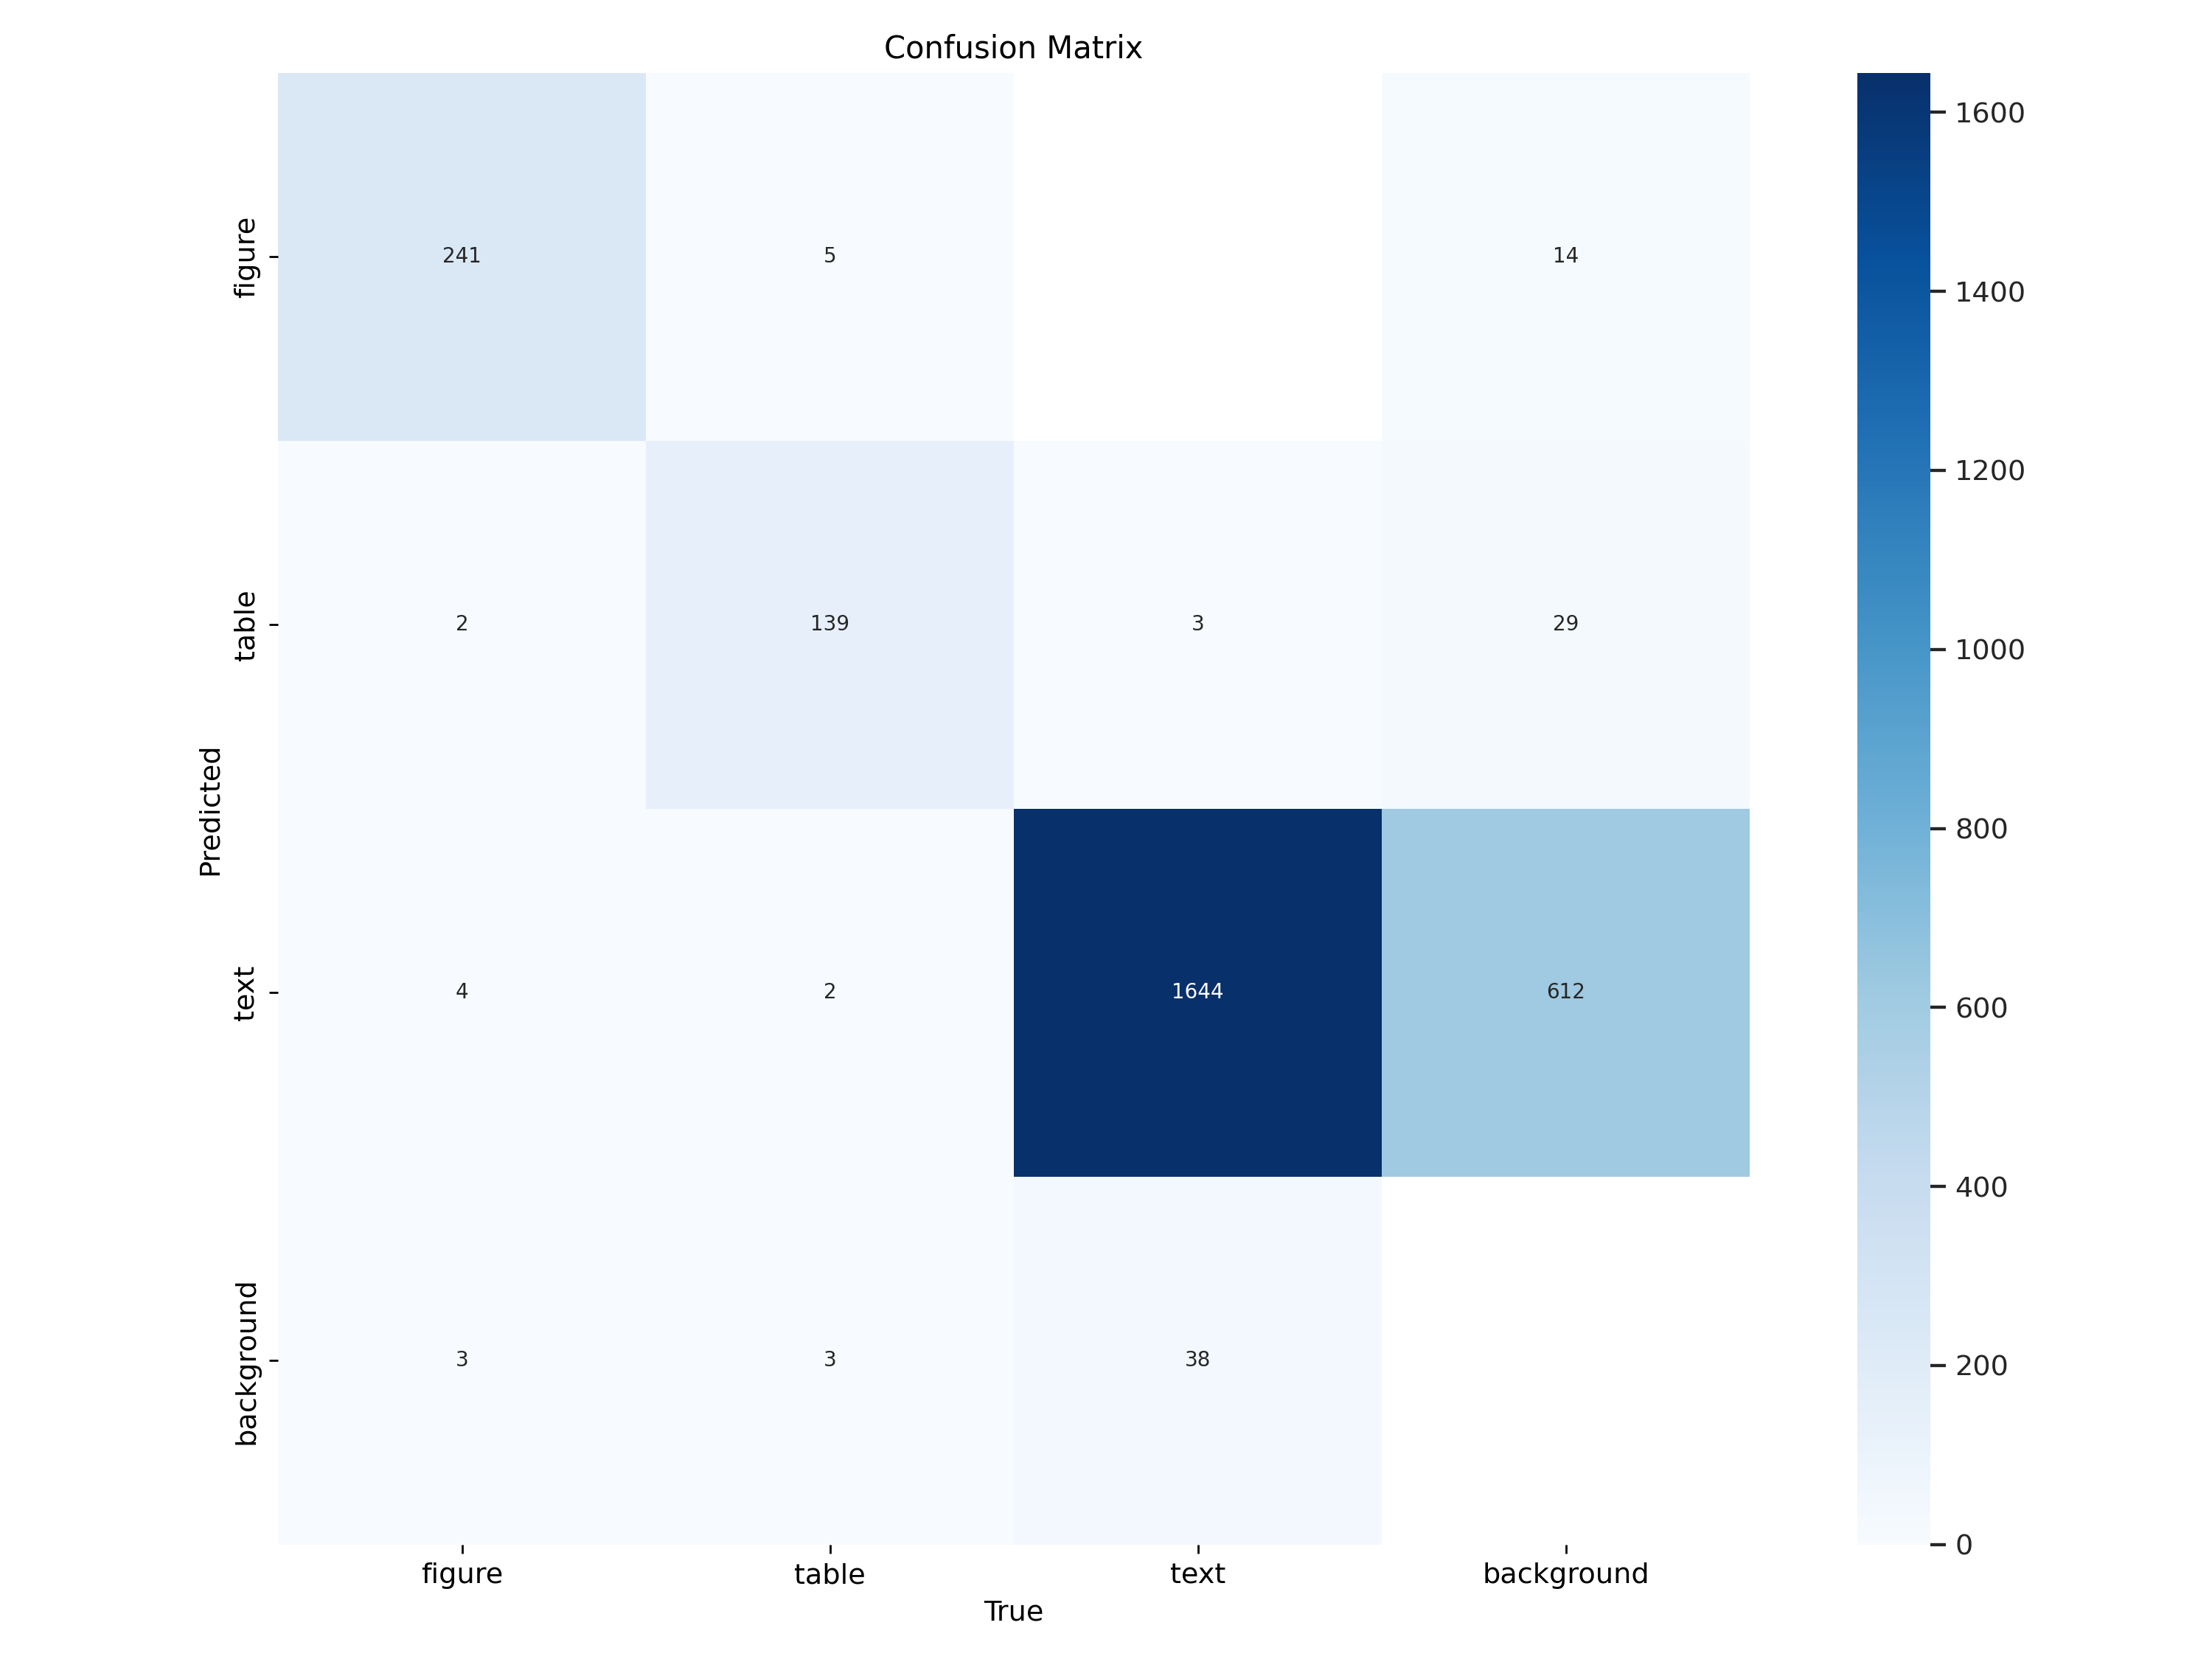

In [35]:
from IPython.display import Image as IPyimage

IPyimage(filename = f'{HOME}/runs/detect/train/confusion_matrix.png',width=600)

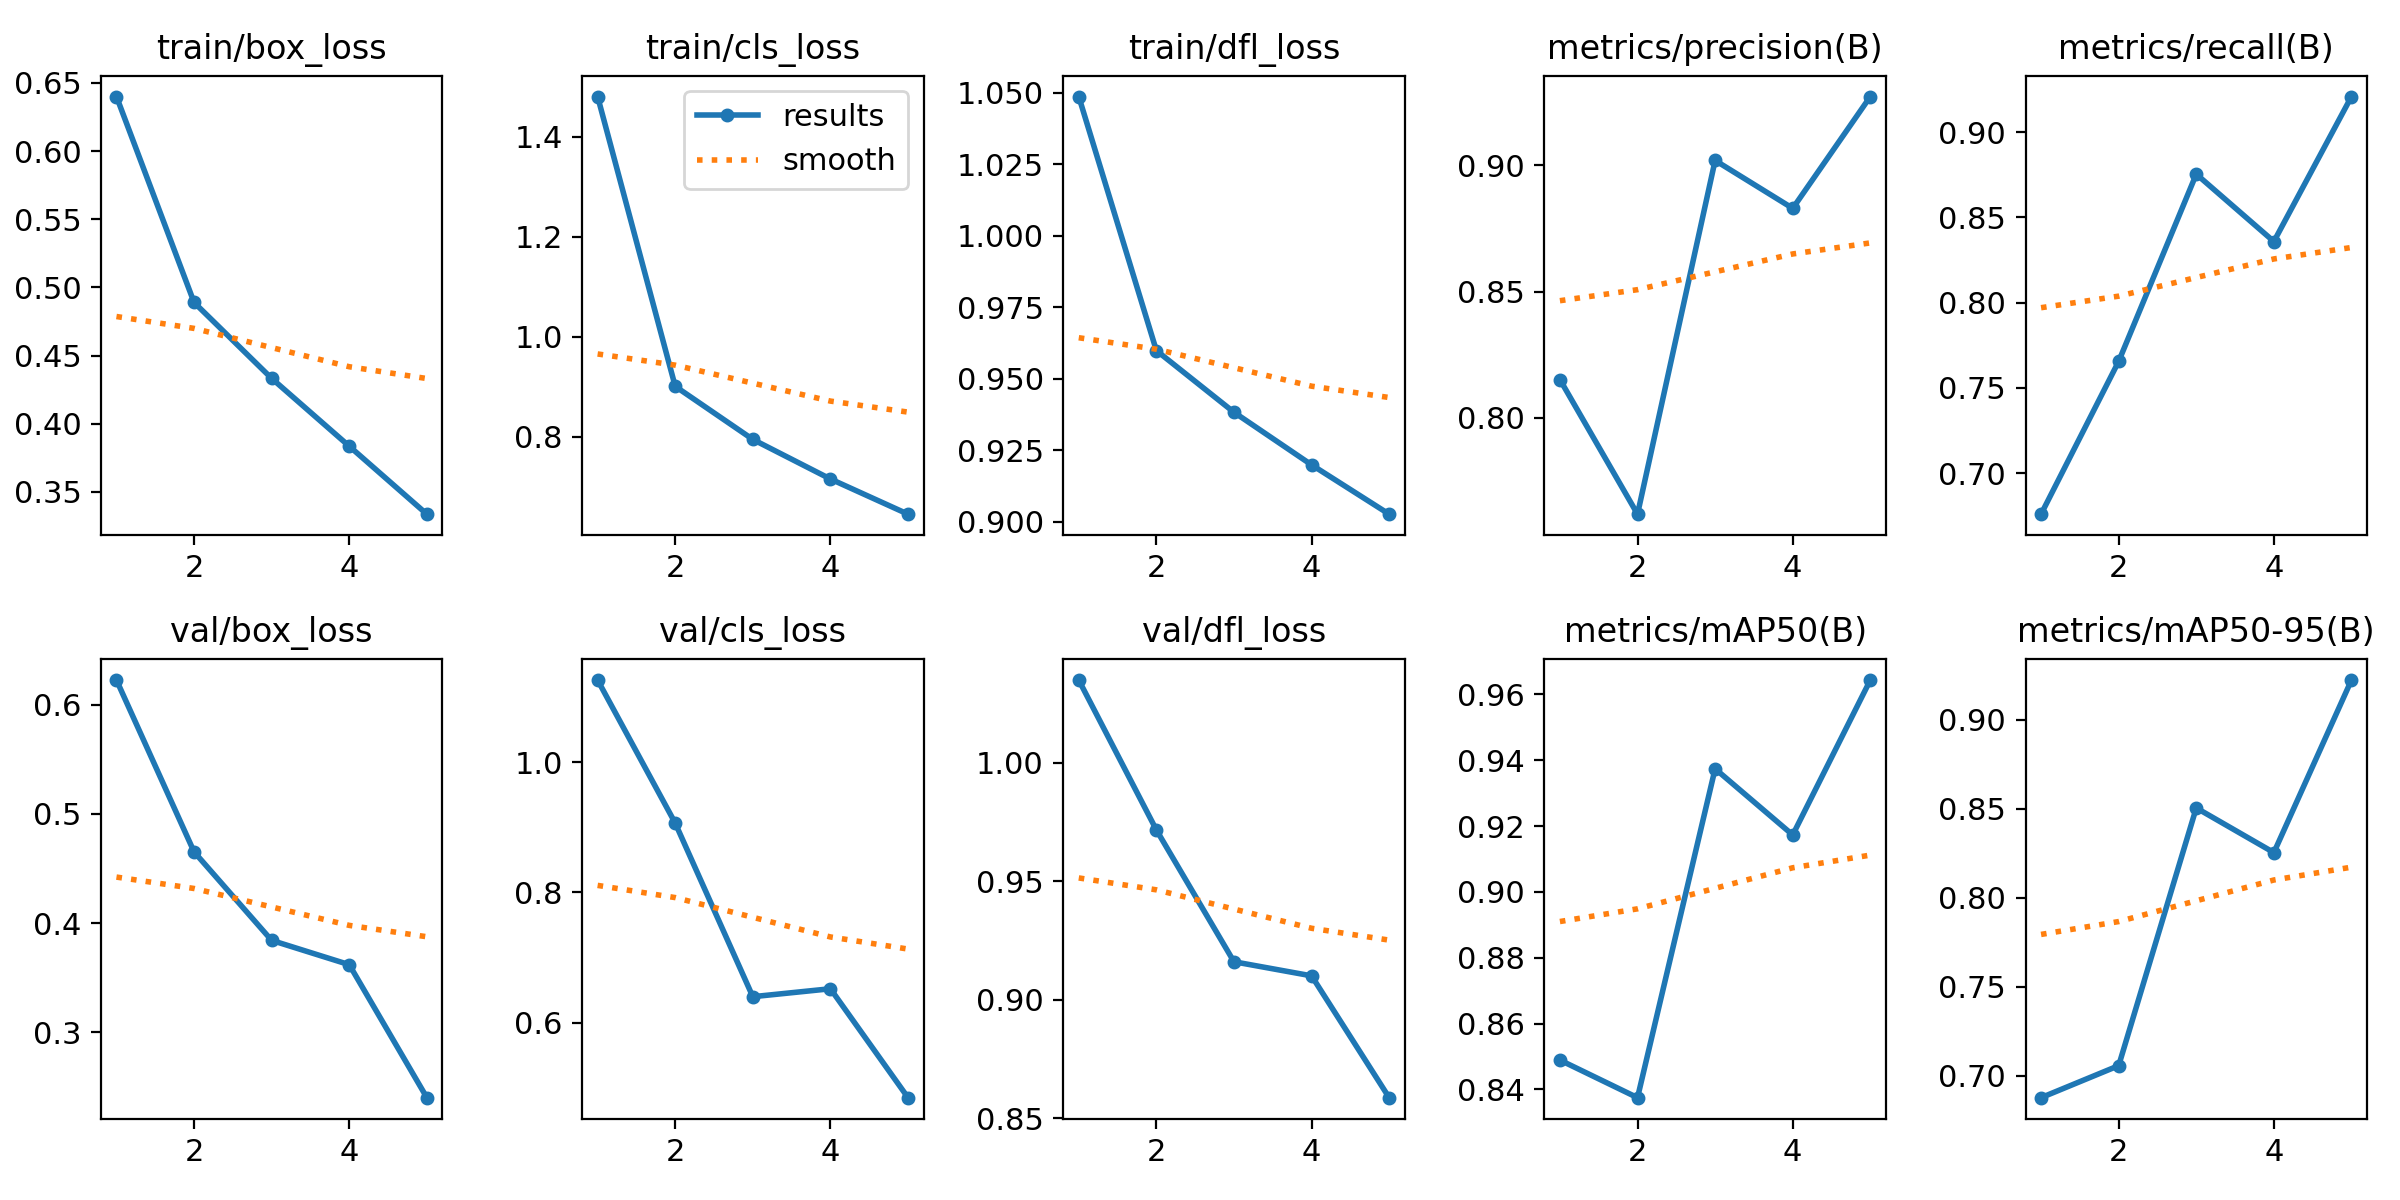

In [36]:
from IPython.display import Image as IPyimage

IPyimage(filename = f'{HOME}/runs/detect/train/results.png',width=600)

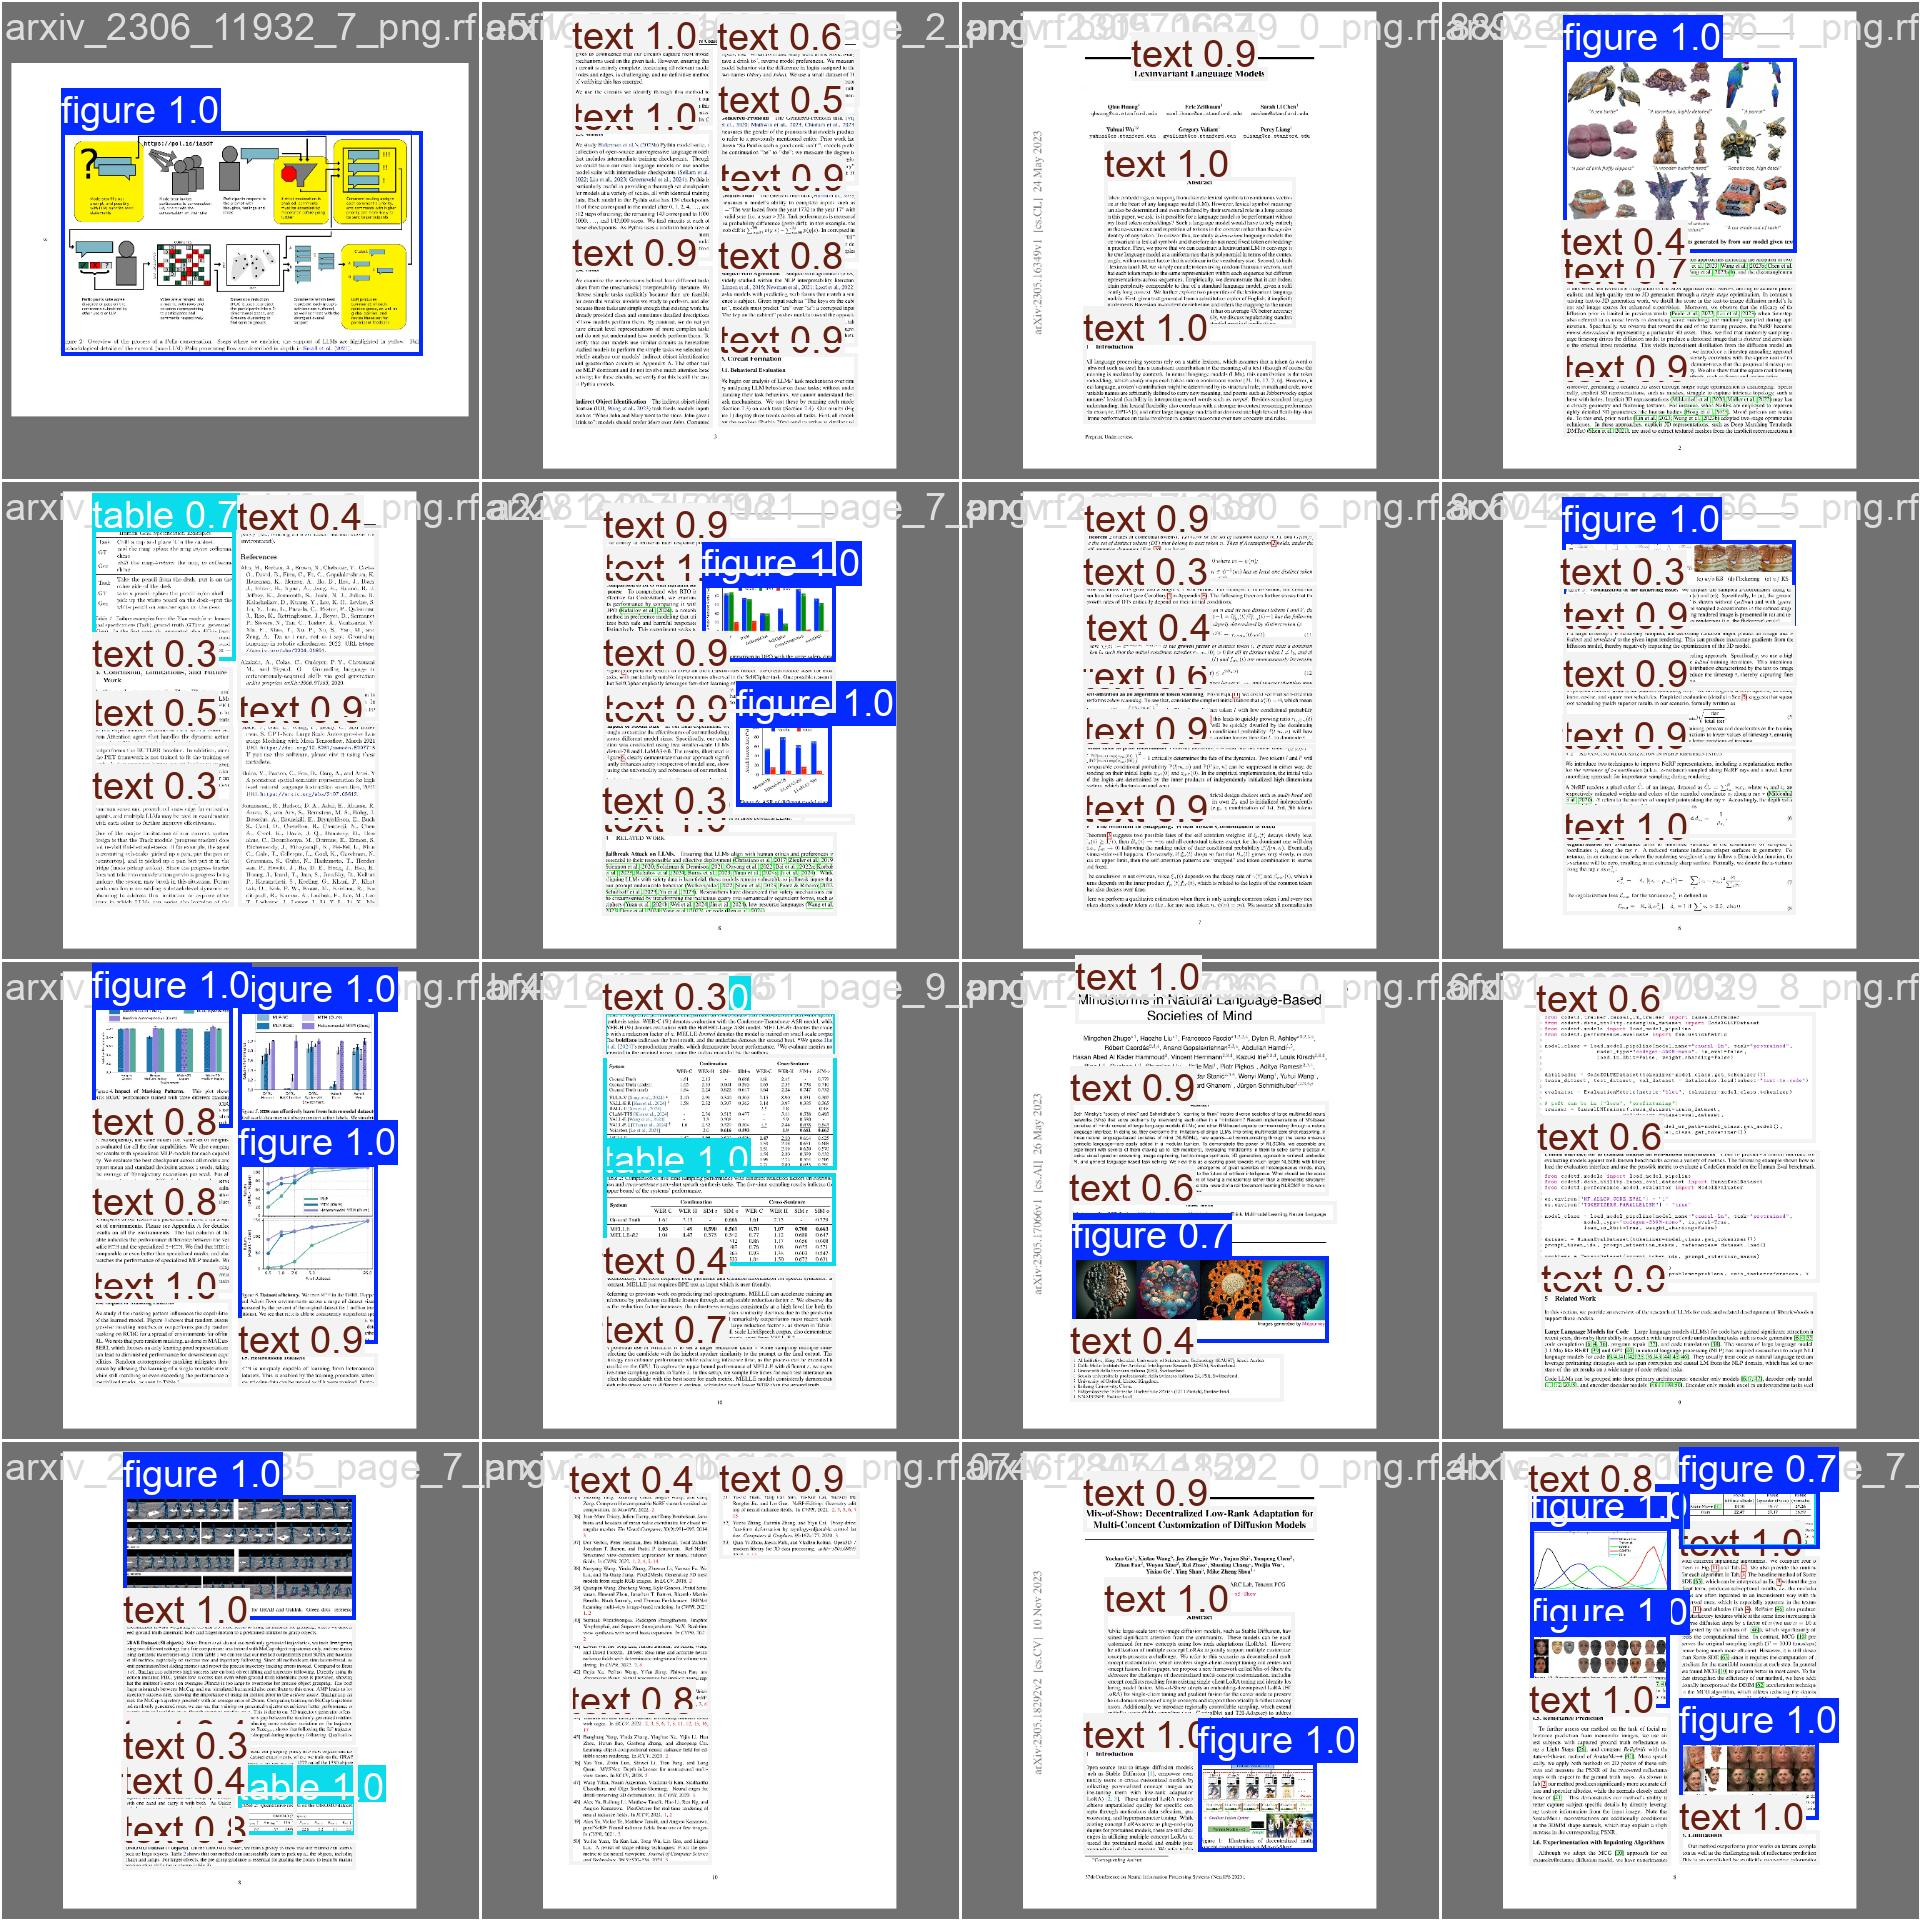

In [37]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=640)

# Validate fine-tuned model

In [38]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.50 source={dataset.location}/test/images save=True

Ultralytics 8.3.121 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

image 1/430 /content/TFT-ID-1/test/images/arxiv_2305_02412_3_png.rf.32f6409a183be4b92c631c71a6d780b9.jpg: 640x512 2 figures, 3 texts, 44.0ms
image 2/430 /content/TFT-ID-1/test/images/arxiv_2305_02412_7_png.rf.7b62359e54e4d3351b4b13cc753c08ec.jpg: 640x512 1 figure, 2 tables, 3 texts, 13.6ms
image 3/430 /content/TFT-ID-1/test/images/arxiv_2305_02665_4_png.rf.815a85a442d156cdad1178f7f6952bd4.jpg: 640x480 1 figure, 4 texts, 68.5ms
image 4/430 /content/TFT-ID-1/test/images/arxiv_2305_02968_3_png.rf.36f288a156a4db6c10e060bdd912bdf2.jpg: 640x512 1 figure, 4 texts, 15.6ms
image 5/430 /content/TFT-ID-1/test/images/arxiv_2305_03689_0_png.rf.772b06c466575a3872bd3ff29c72b9bd.jpg: 640x512 3 texts, 11.8ms
image 6/430 /content/TFT-ID-1/test/images/arxiv_2305_03981_7_png.rf.c9f67ee6cda1d43dda4e593bc592312a.jpg: 640x480 2 figures, 1 table

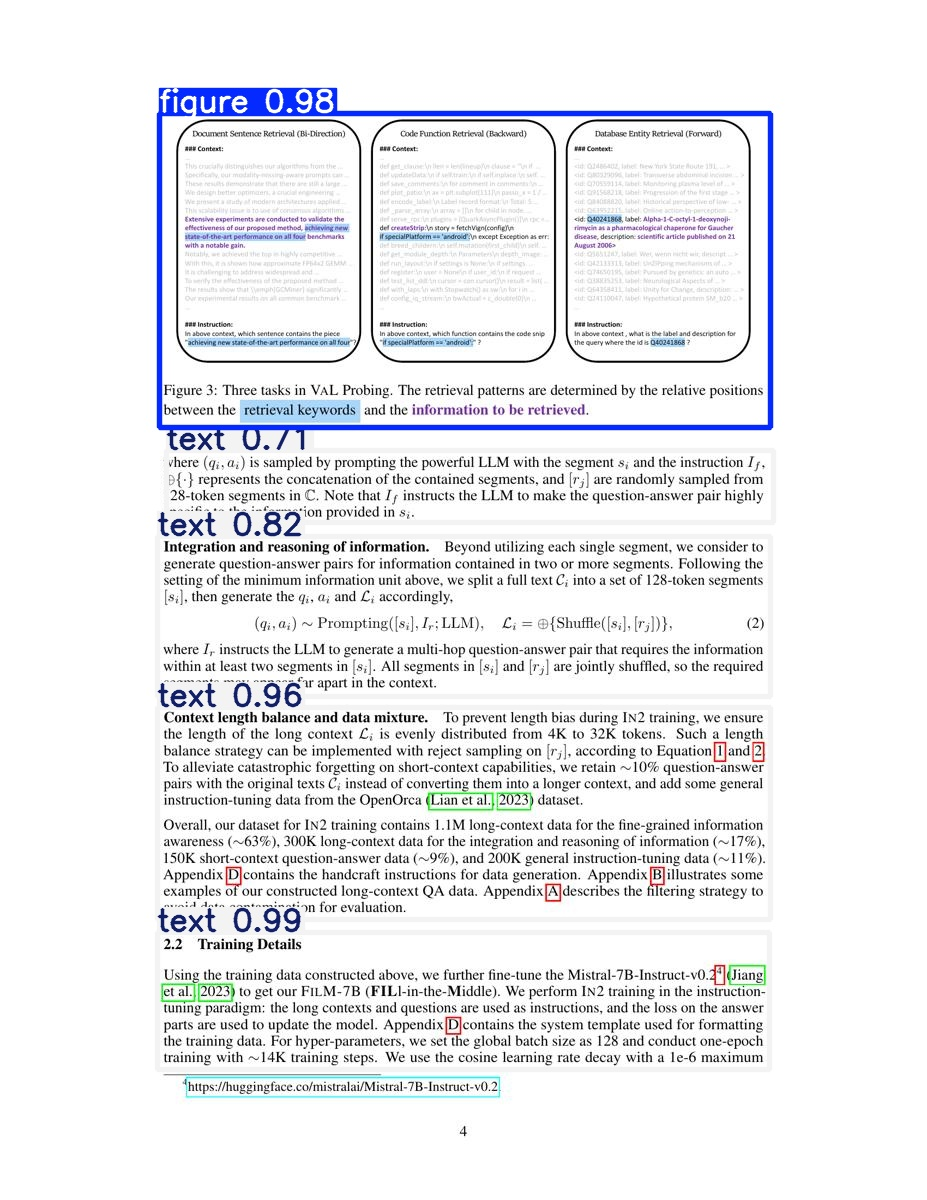

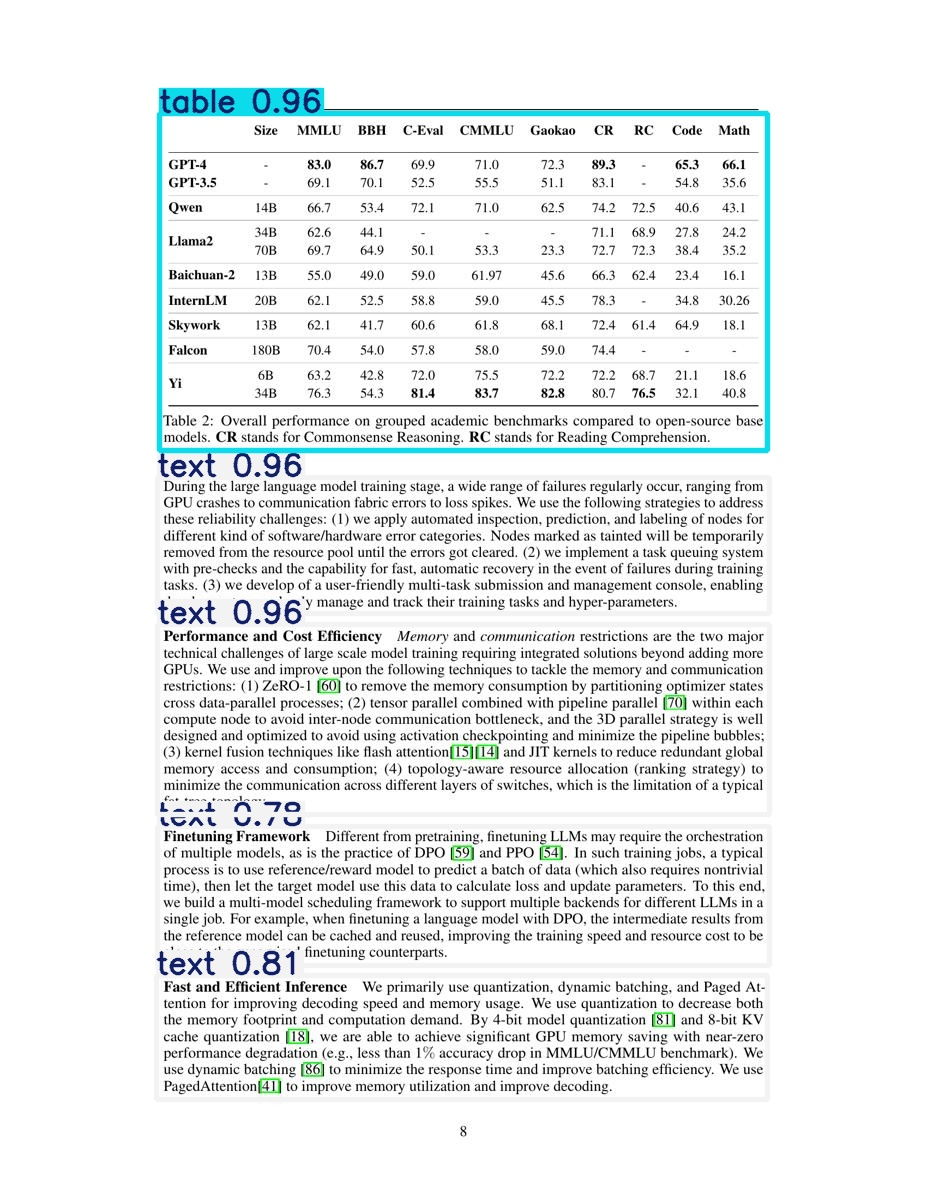

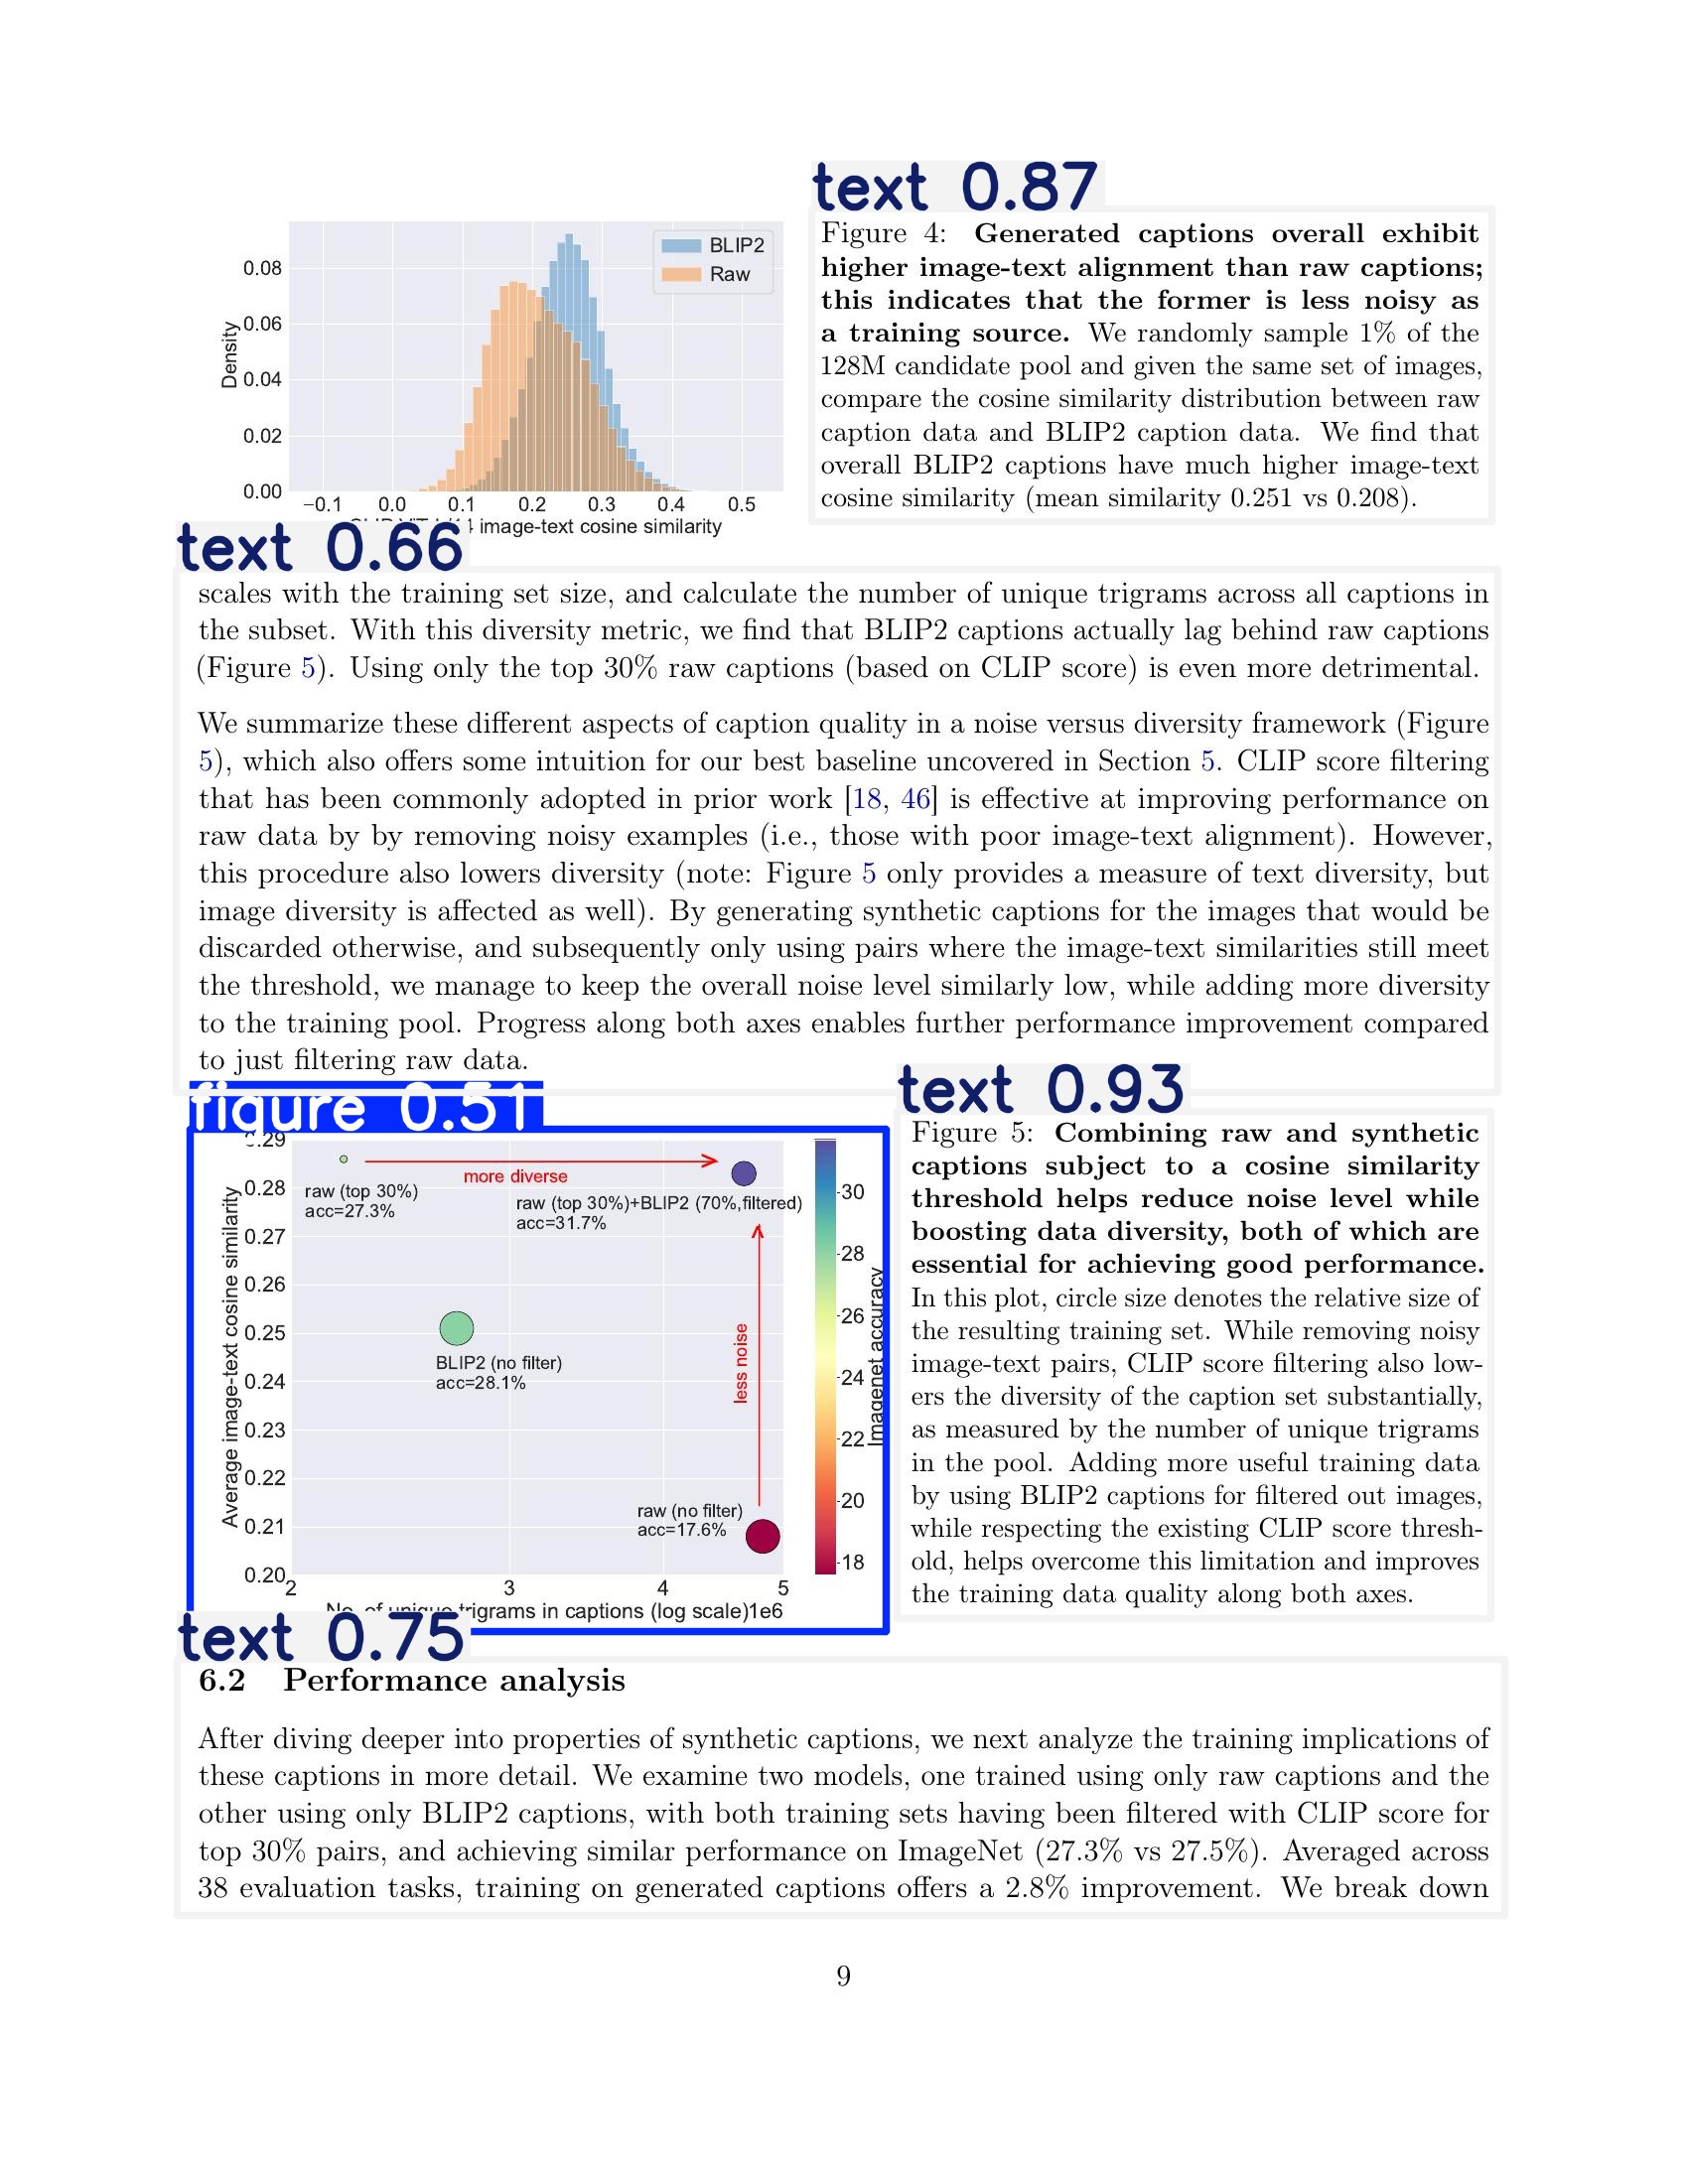

In [39]:
import os
import glob
from IPython.display import Image as IPyImage

latest_folder = max(glob.glob('/content/runs/detect/predict'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
  display(IPyImage(filename=img))
  print("\n")



# Loading the model in a new variable

In [40]:
model_loaded = '/content/runs/detect/train/weights/best.pt'

Running inference on:arxiv_2404_12387_5_png.rf.893e339bb1a3ed030757e5828b5f0a2d.jpg

0: 640x512 1 table, 5 texts, 17.4ms
Speed: 4.8ms preprocess, 17.4ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 512)


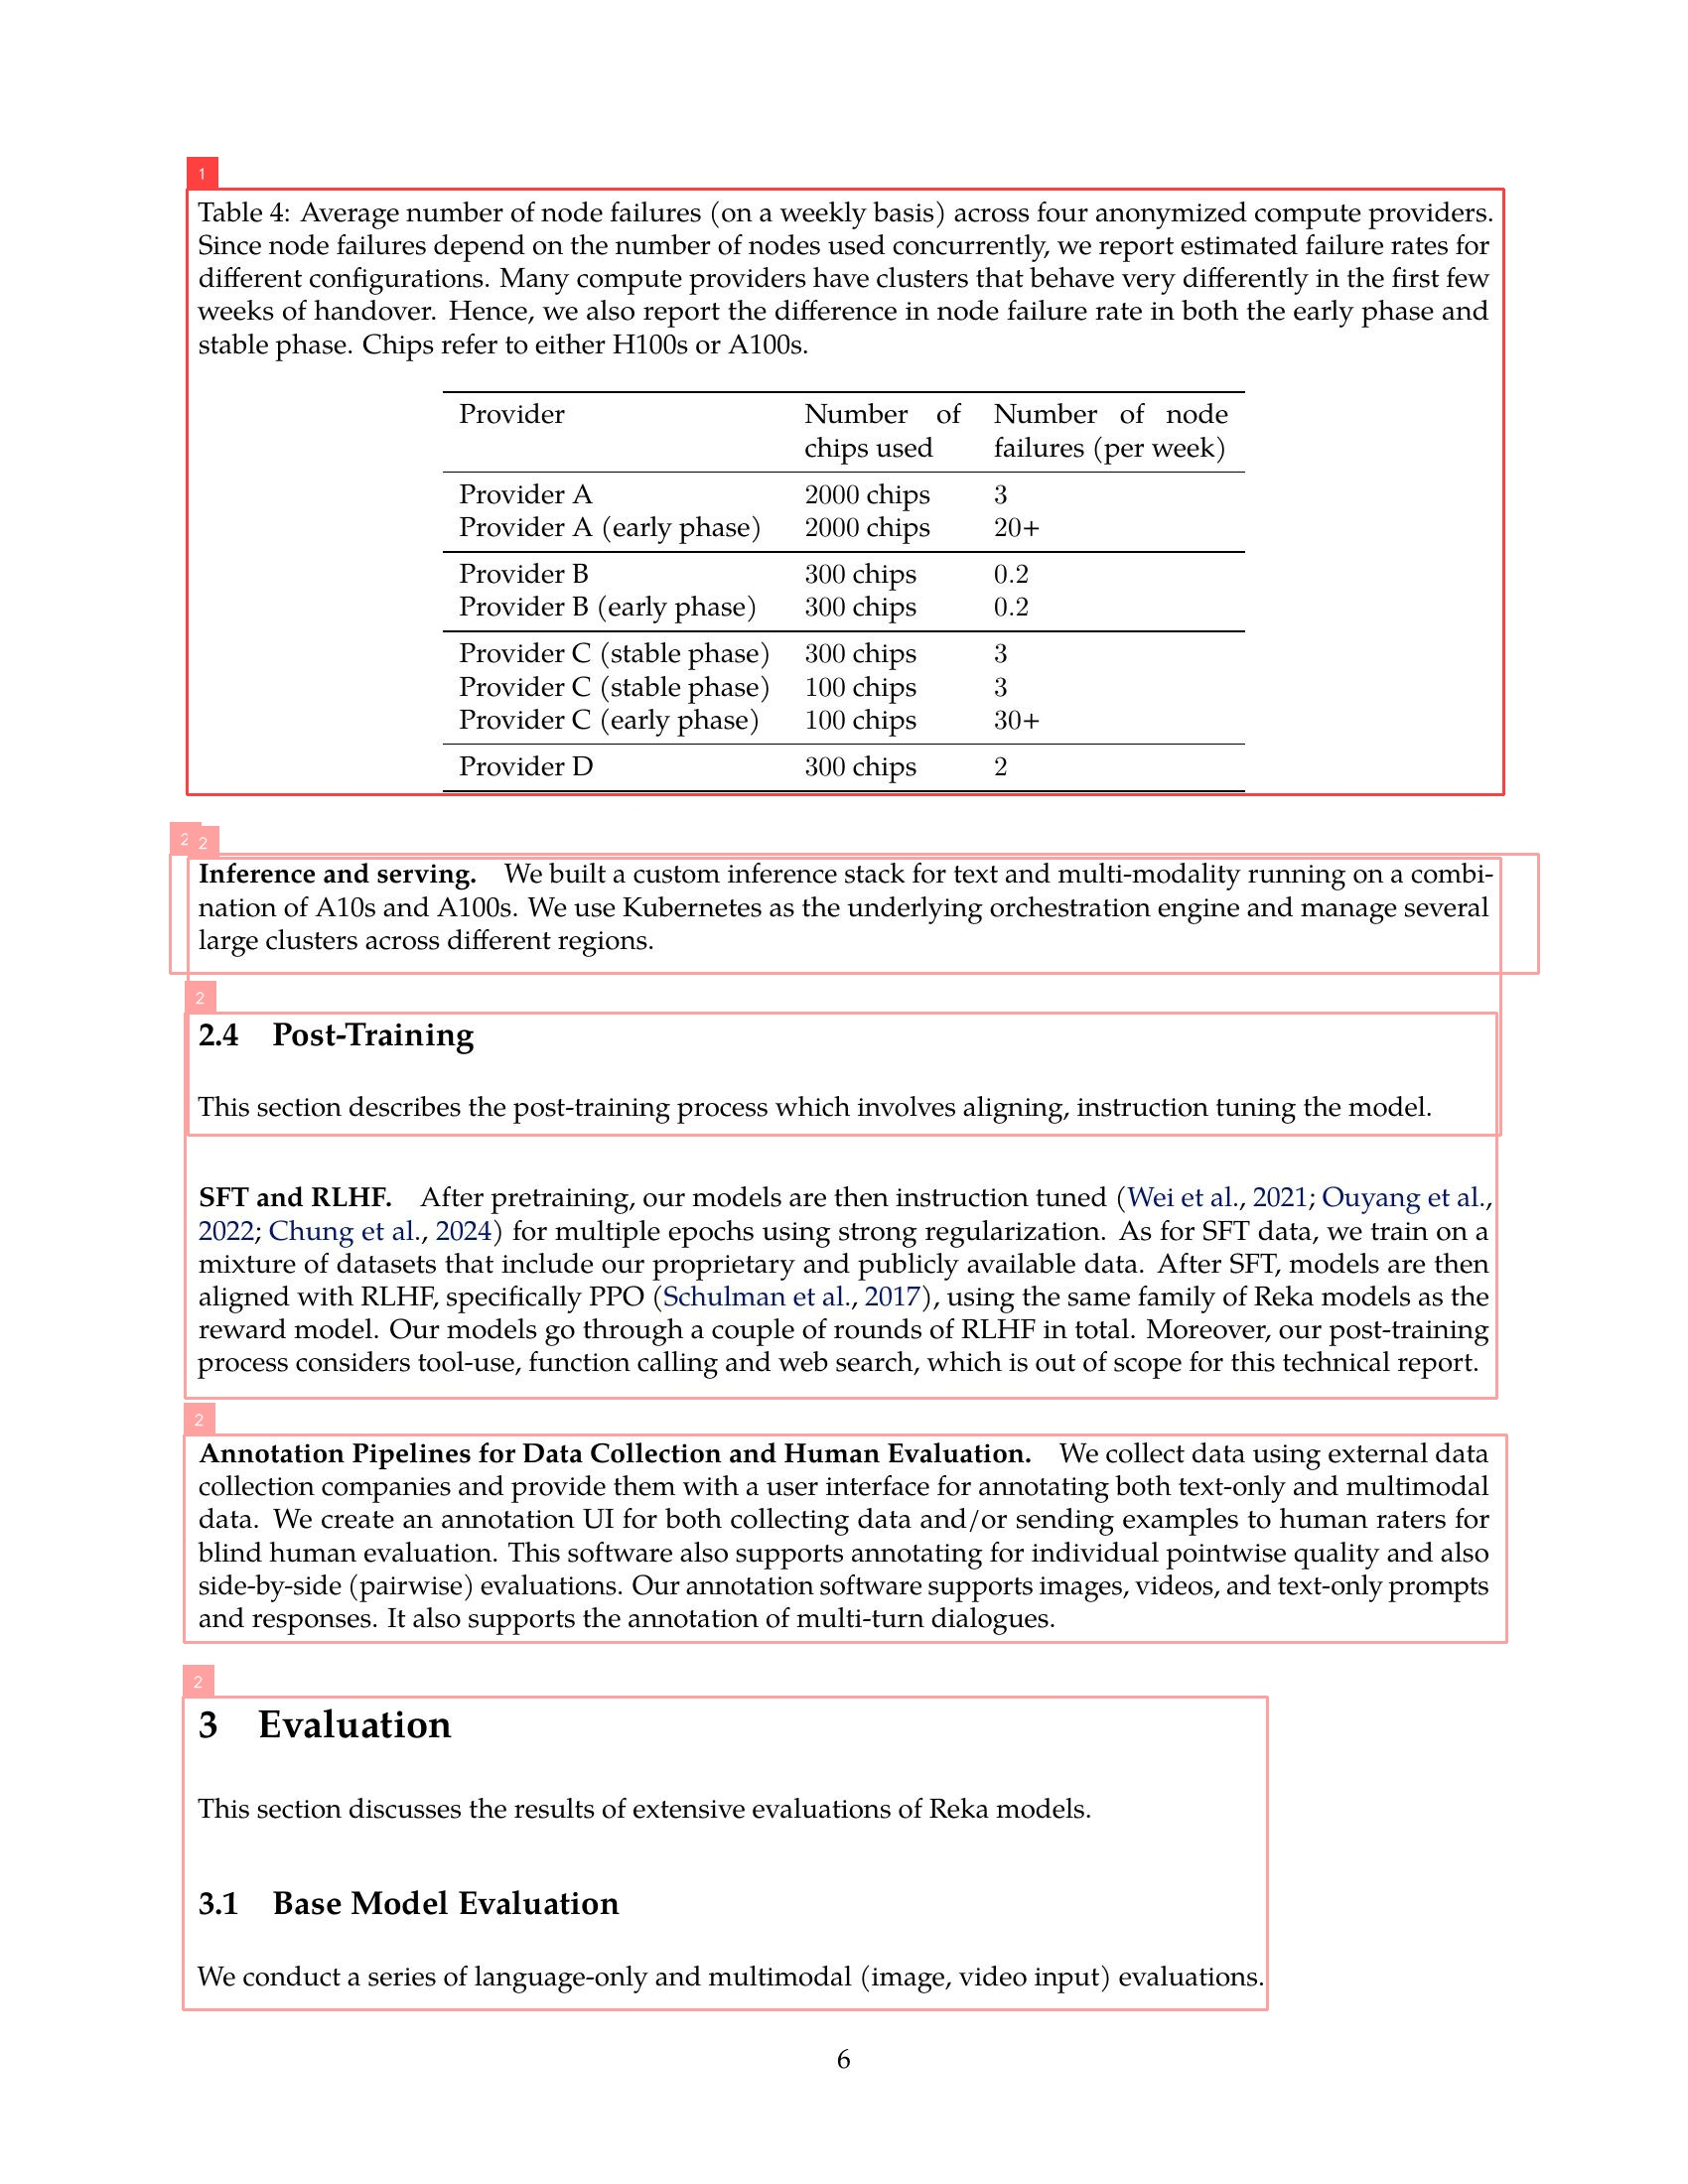

Running inference on:arxiv_2308_01317_8_png.rf.f566c2deb3215fc9ee00d2e5c8b4d367.jpg

0: 640x480 5 texts, 99.9ms
Speed: 6.9ms preprocess, 99.9ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 480)


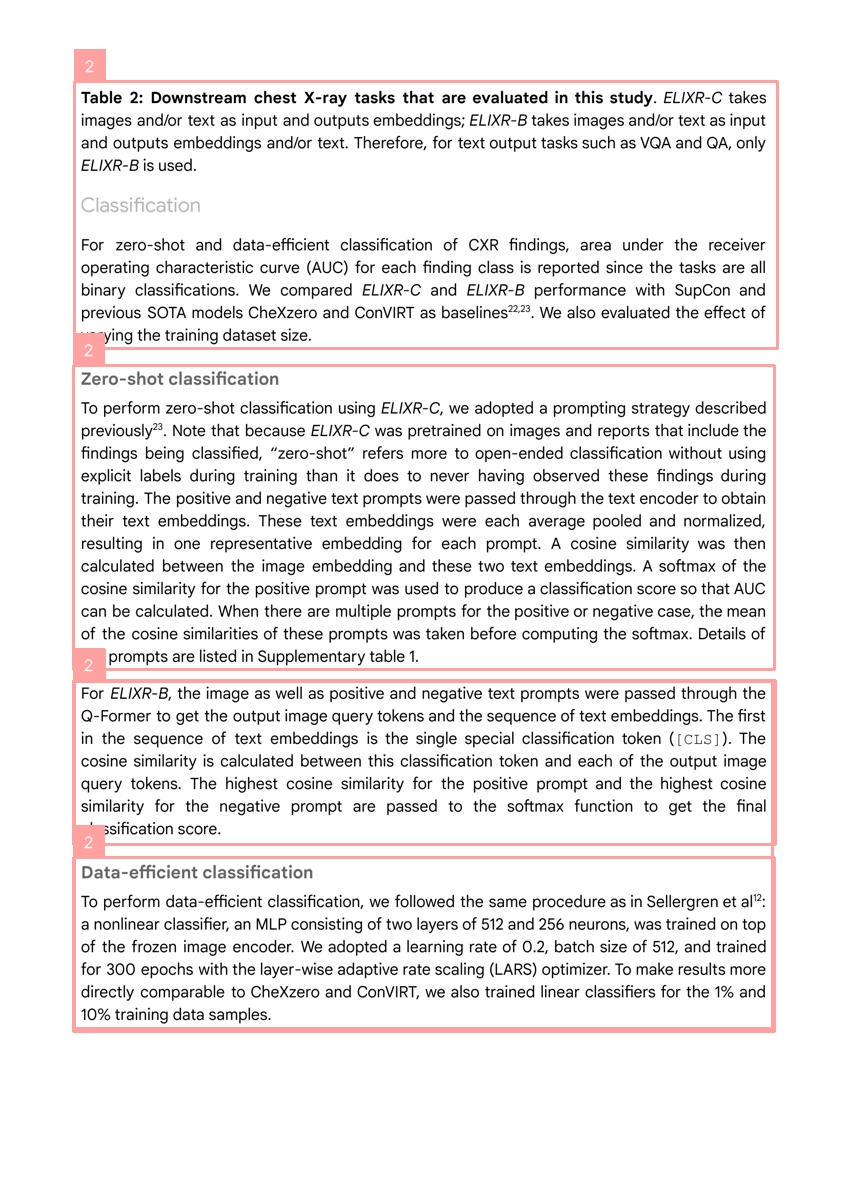

Running inference on:arxiv_2310_10837_2_png.rf.8918b1444009ba3e20c5dda8c37e8ebc.jpg

0: 640x480 1 figure, 7 texts, 16.7ms
Speed: 3.9ms preprocess, 16.7ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)


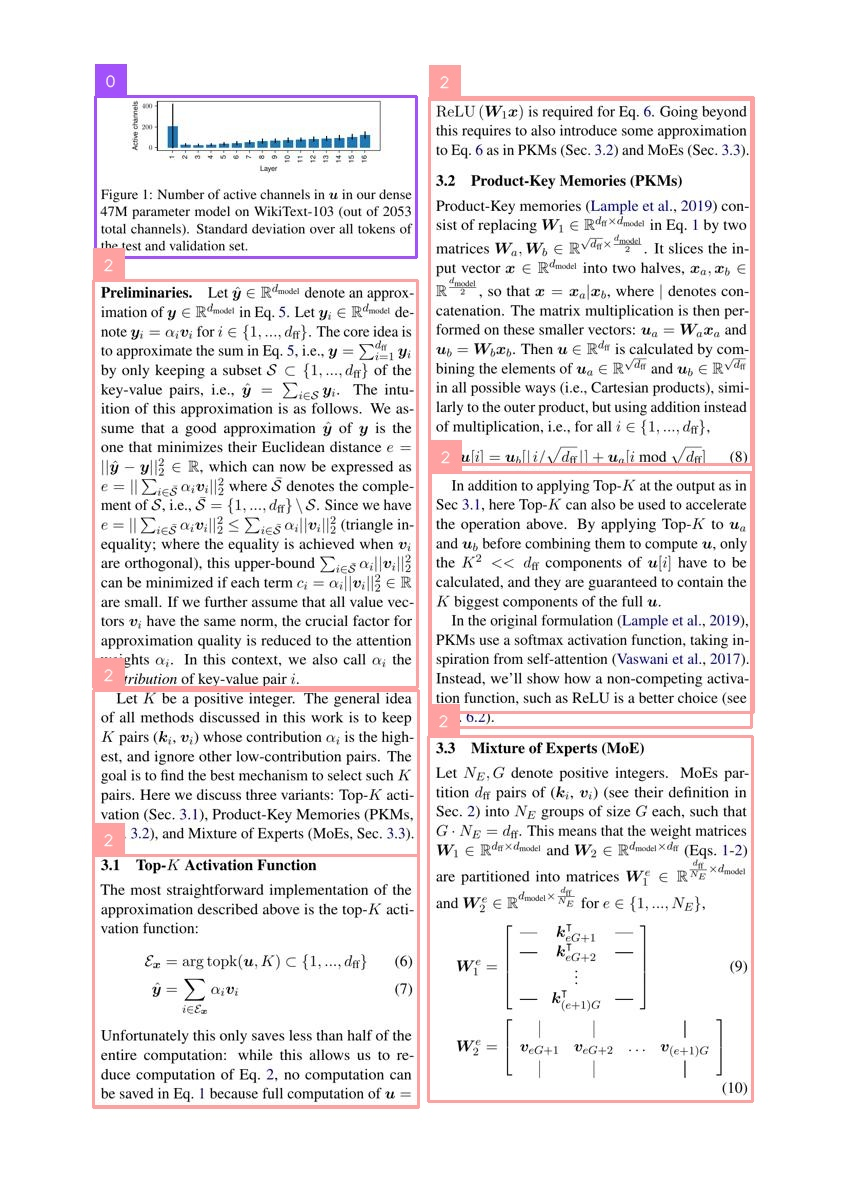

Running inference on:arxiv_2405_19893_1_png.rf.c452cd6c9b7f0ff3a73168e63b8c057a.jpg

0: 640x480 1 figure, 4 texts, 14.5ms
Speed: 4.8ms preprocess, 14.5ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 480)


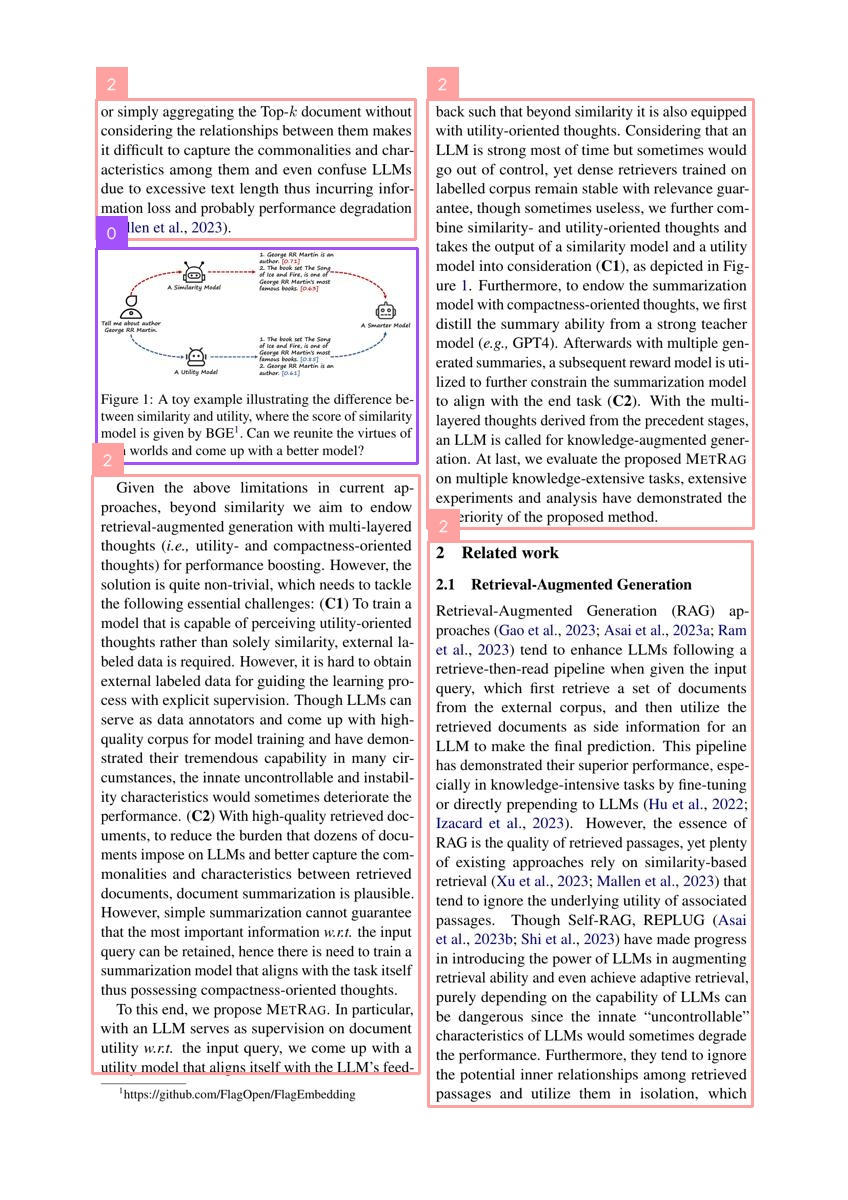

In [43]:
#INFERENCE

import os
import random
import cv2
import supervision as sv
import IPython
from ultralytics import YOLO

#loading the custom model
model_loaded = YOLO('/content/runs/detect/train/weights/best.pt')

#assuming the dataset is located in variable if not replace with the actual path and the train path
test_set_loc = dataset.location + "/test/images/"
test_images = os.listdir(test_set_loc)

#running inference on any random 4 images
for img_name in random.sample(test_images,min(4,len(test_images))):
  print("Running inference on:"+img_name)

  #load  the image
  image_path = os.path.join(test_set_loc,img_name)
  image = cv2.imread(image_path)

  #run inference
  result = model_loaded(image,conf=0.4)[0]#confidence threshold set  to 0.4

  #convert results to supervision detections
  detections = sv.Detections(
      xyxy=result.boxes.xyxy.cpu().numpy(),
      confidence=result.boxes.conf.cpu().numpy(),
      class_id=result.boxes.cls.cpu().numpy().astype(int)
  )

  #annotate boxes and labels

  box_annotator = sv.BoxAnnotator()
  label_annotator = sv.LabelAnnotator()
  annotated_image = box_annotator.annotate(scene=image,detections=detections)
  annotated_image = label_annotator.annotate(scene=annotated_image,detections=detections)

  #Display annotated images
  _,buffer = cv2.imencode(".jpg",annotated_image)
  i = IPython.display.Image(data=buffer)
  IPython.display.display(i)




0: 640x512 2 figures, 3 texts, 12.9ms
Speed: 3.2ms preprocess, 12.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 512)


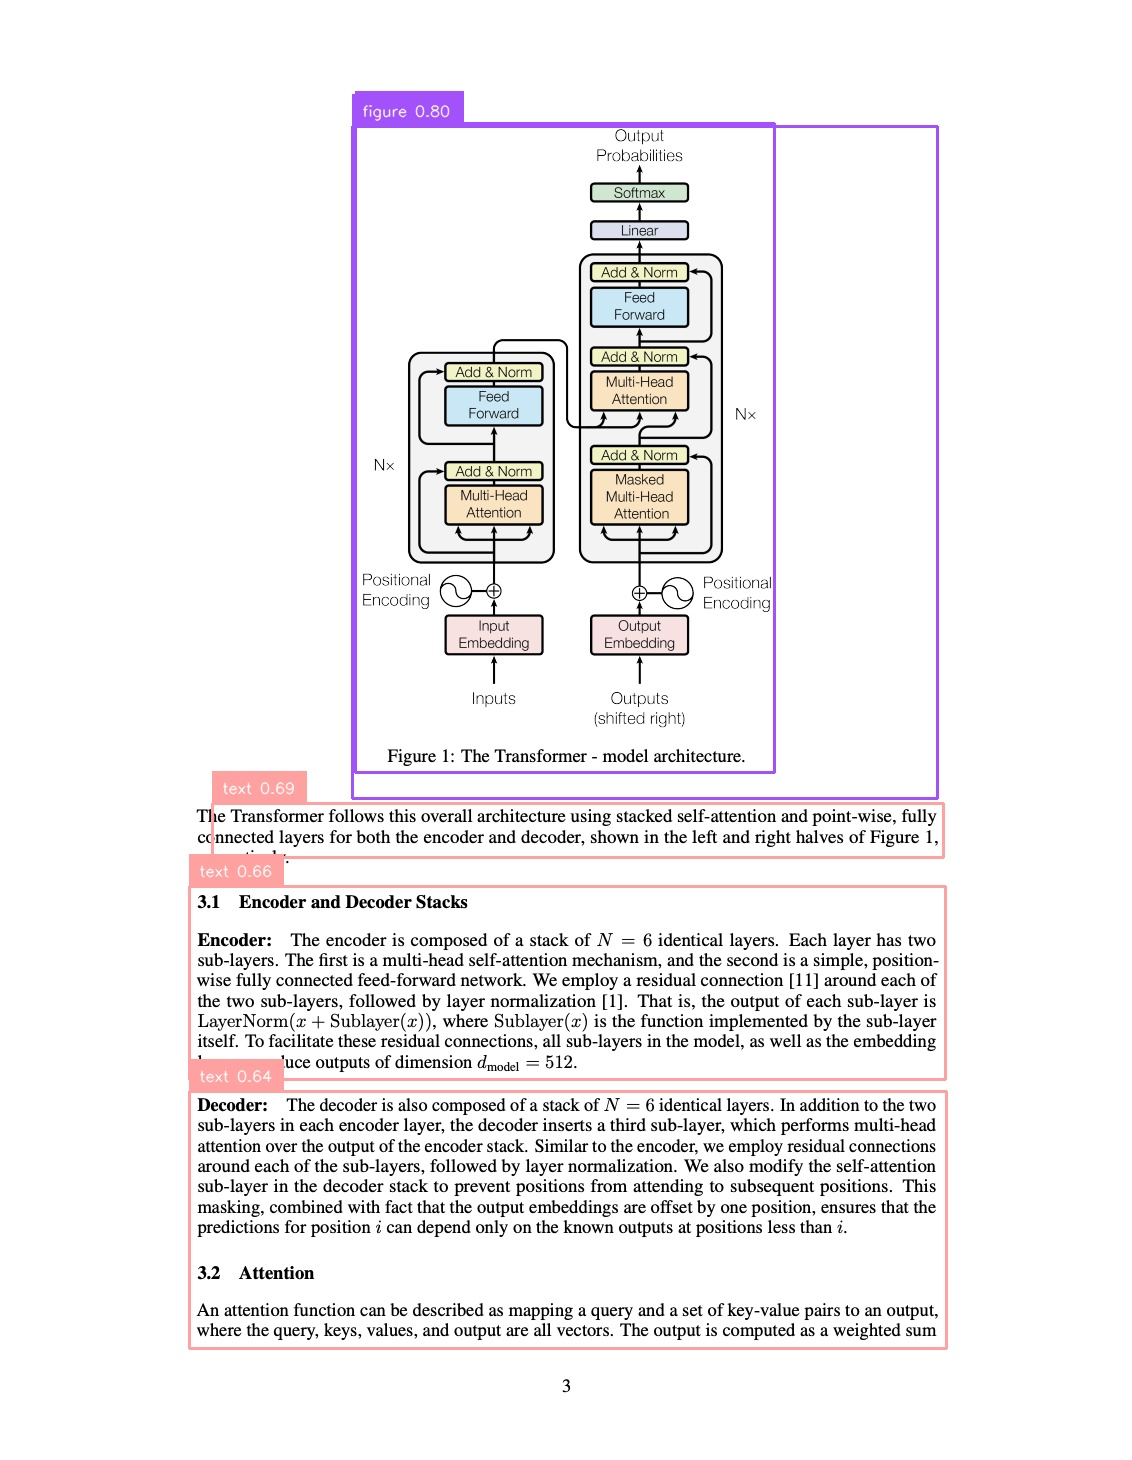

Number of detections: 5
Detection: figure, Confidence: 0.86, Coordinates: [     355.62      123.03      774.12      772.22]
Detection: figure, Confidence: 0.80, Coordinates: [     352.44      126.68      937.85      798.75]
Detection: text, Confidence: 0.69, Coordinates: [     212.31      803.09      943.97      857.75]
Detection: text, Confidence: 0.66, Coordinates: [     189.87      886.95       945.4      1079.4]
Detection: text, Confidence: 0.64, Coordinates: [     189.51      1091.2      946.21      1348.6]


In [45]:
import cv2
import supervision as sv
from ultralytics import YOLO
import IPython

# Load the custom model
model_loaded = YOLO('/content/runs/detect/train/weights/best.pt')

# Specify the path to your single image
image_path = '/content/download.png'  # Replace with your actual image path

# Load image
image = cv2.imread(image_path)

# Perform inference with labels
results = model_loaded(image, conf=0.50)[0]

# Create Detections with labels
detections = sv.Detections(
    xyxy=results.boxes.xyxy.cpu().numpy(),
    confidence=results.boxes.conf.cpu().numpy(),
    class_id=results.boxes.cls.cpu().numpy().astype(int)
)

# Get class names from the model
class_names = model_loaded.names

# Annotate boxes and labels with class names
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(
    text_scale=0.5,  # Adjust text size if needed
    text_thickness=1,  # Adjust text thickness  # You can customize color palette
)

# Annotate the image with detections and their labels
annotated_image = box_annotator.annotate(scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image,
    detections=detections,
    labels=[f"{class_names[class_id]} {confidence:.2f}" for class_id, confidence in zip(detections.class_id, detections.confidence)]
)

# Display annotated image
_, buffer = cv2.imencode('.jpg', annotated_image)
i = IPython.display.Image(data=buffer)
IPython.display.display(i)

# Print detection details
print("Number of detections:", len(detections))
for box, conf, cls in zip(detections.xyxy, detections.confidence, detections.class_id):
    print(f"Detection: {class_names[cls]}, Confidence: {conf:.2f}, Coordinates: {box}")